# K-means

**k-means** - один из алгоритмов кластеризации. Он разбивает даннве на k групп так, чтобы объекты внутри одной группы были максимально похожи друг на друга.

**Алгоритм**:
1. задаем число кластеров k
2. случайно выбираем k центров (центроидов)
3. для каждой точки:
    - считаем расстояние до всех центров
    - относим точку к ближайшему
4. пересчитываем центры кластеров (среднее всех точек в кластере)
5. повторяем шаги 3–4, пока центры не перестанут меняться

Для расчета расстояния обычно используют эвклидово расстояние. 

**Плюсы**: простой и быстрый, хорошо работает на больших данных.

**Минусы**: нужно заранее знать k, плохо работает с кластерами сложной формы и чувствителен к выбросам.

In [1]:
# Блок с используемыми библиотеками
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
# Блок с описанием и демонстрацией
df = pd.read_csv("../datasets/spotify_tracks.csv", sep=",")
df.head()

,track_id,track_name,artist_name,album_name,release_year,genre,popularity,duration_ms,explicit,danceability,...,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,key,mode,time_signature
0,P3fAbnFbmOHnKYaXRvj7uf,One Dance (Acoustic Version),Alex Rodriguez,The Night Album,2024,metal,14,189042,True,0.427723,...,-4.702460,0.050635,0.239506,0.181395,0.133053,0.431384,141.048735,6,0,4
1,M2wleOV911xCZkwPRQeNHp,Forever Song (Remix),Desert Wind,Burning Soul,2019,rock,11,186805,True,0.448634,...,-7.110031,0.000000,0.044463,0.097818,0.435949,0.559135,131.833287,0,1,5
2,4JSnE2NiiUHUAKw9iEU1jj,Last Mountain,The Midnight,The Night Album,2022,k-pop,23,121814,False,0.707923,...,-7.305120,0.144091,0.118380,0.000000,0.262254,0.516873,127.132954,2,1,5
3,2UVvsjaSS8VFgM0Fmxk754,Falling Star (Live),Phantom Keys,Phantom's Greatest Hits,2024,latin,34,216049,False,0.846237,...,-9.527256,0.006668,0.272844,0.000000,0.045332,0.667911,93.041715,0,1,6
4,EeVVhDIq2AnHTmt9OBGhnu,Rising Moon (feat. someone),Desert Wind,Rising Soul,2010,latin,31,156170,False,0.943720,...,-9.017653,0.057632,0.219752,0.098044,0.132083,0.772151,93.404975,7,1,4


In [3]:
# Блок с предварительной обработкой датасета

df.info()

# заменим жанры на категории

df_genre = df.copy()
df_genre = pd.get_dummies(df, columns=['genre'], drop_first=True)

df_tr = df_genre
df_tr.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   track_id          50000 non-null  str    
 1   track_name        50000 non-null  str    
 2   artist_name       50000 non-null  str    
 3   album_name        50000 non-null  str    
 4   release_year      50000 non-null  int64  
 5   genre             50000 non-null  str    
 6   popularity        50000 non-null  int64  
 7   duration_ms       50000 non-null  int64  
 8   explicit          50000 non-null  bool   
 9   danceability      50000 non-null  float64
 10  energy            50000 non-null  float64
 11  loudness          50000 non-null  float64
 12  speechiness       50000 non-null  float64
 13  acousticness      50000 non-null  float64
 14  instrumentalness  50000 non-null  float64
 15  liveness          50000 non-null  float64
 16  valence           50000 non-null  float64
 17  temp

In [4]:
X = df_tr.drop(['track_id', 'track_name', 'artist_name', 'album_name', 'release_year', 'time_signature', 'duration_ms', 'popularity'], 
               axis=1) 

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

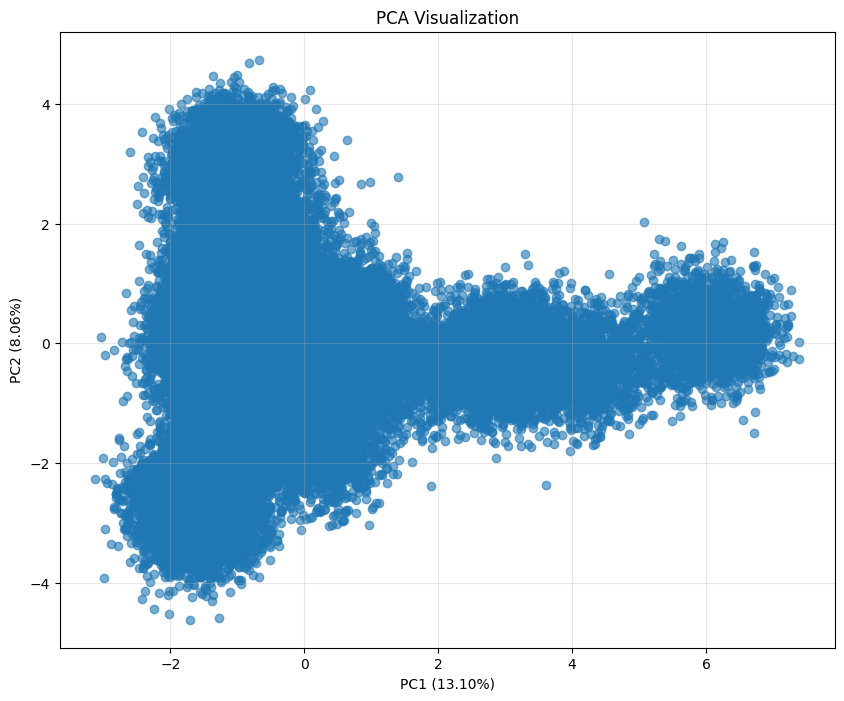

In [49]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)

# Визуализация
plt.figure(figsize=(10, 8))
plt.scatter(pca_result[:, 0], pca_result[:, 1], alpha=0.6)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')
plt.title('PCA Visualization')
plt.grid(True, alpha=0.3)
plt.show()

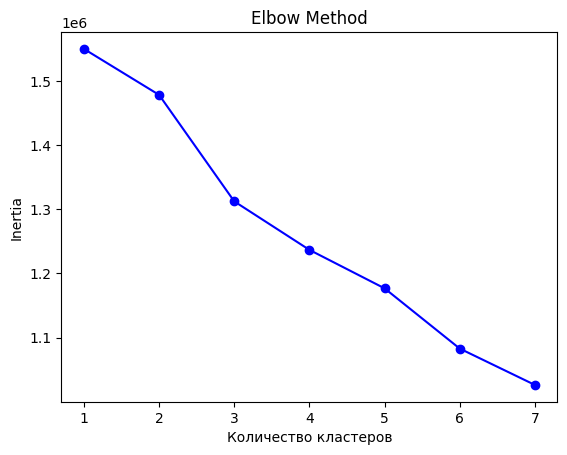

In [45]:
# подбор количества кластеров (Elbow Method)

inertia = []

K = range(1, 8)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=6769)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(K, inertia, 'bo-')
plt.xlabel('Количество кластеров')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [72]:
kmeans = KMeans(n_clusters=3, random_state=6769)
clusters = kmeans.fit_predict(X_scaled)

df['cluster'] = clusters
df.head()

,track_id,track_name,artist_name,album_name,release_year,genre,popularity,duration_ms,explicit,danceability,...,speechiness,acousticness,instrumentalness,liveness,valence,tempo,key,mode,time_signature,cluster
0,P3fAbnFbmOHnKYaXRvj7uf,One Dance (Acoustic Version),Alex Rodriguez,The Night Album,2024,metal,14,189042,True,0.427723,...,0.050635,0.239506,0.181395,0.133053,0.431384,141.048735,6,0,4,0
1,M2wleOV911xCZkwPRQeNHp,Forever Song (Remix),Desert Wind,Burning Soul,2019,rock,11,186805,True,0.448634,...,0.000000,0.044463,0.097818,0.435949,0.559135,131.833287,0,1,5,1
2,4JSnE2NiiUHUAKw9iEU1jj,Last Mountain,The Midnight,The Night Album,2022,k-pop,23,121814,False,0.707923,...,0.144091,0.118380,0.000000,0.262254,0.516873,127.132954,2,1,5,1
3,2UVvsjaSS8VFgM0Fmxk754,Falling Star (Live),Phantom Keys,Phantom's Greatest Hits,2024,latin,34,216049,False,0.846237,...,0.006668,0.272844,0.000000,0.045332,0.667911,93.041715,0,1,6,1
4,EeVVhDIq2AnHTmt9OBGhnu,Rising Moon (feat. someone),Desert Wind,Rising Soul,2010,latin,31,156170,False,0.943720,...,0.057632,0.219752,0.098044,0.132083,0.772151,93.404975,7,1,4,1


In [58]:
score = silhouette_score(X_scaled, clusters)
print("Silhouette Score:", score)

Silhouette Score: 0.1483967376562336


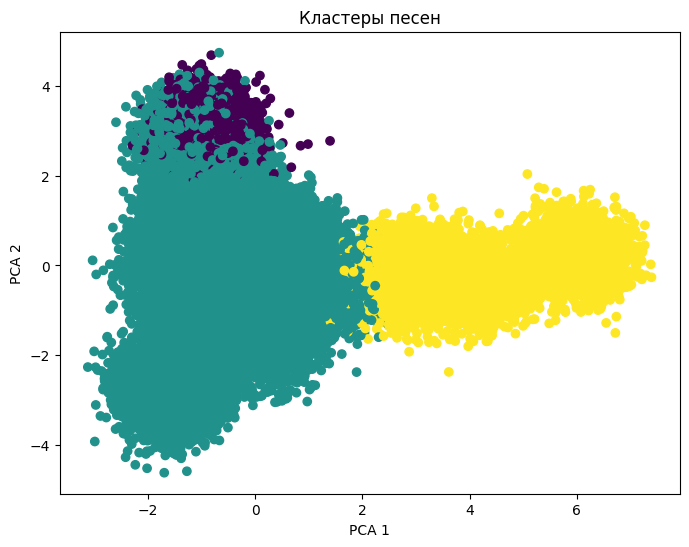

In [73]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, cmap='viridis')
plt.title("Кластеры песен")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

# K-means++

**K-means++** — это улучшенная версия классического алгоритма K-means, которая решает проблему случайной инициализации центроидов.

**Алгоритм**:
1) Выбрать первый центроид случайно из точек данных
2) Для каждой точки вычислить расстояние до ближайшего центроида
3) Выбрать следующий центроид с вероятностью, пропорциональной квадрату расстояния
4) Повторять шаги 2-3 пока не выбраны все k центроидов
5) Запустить стандартный K-means

In [67]:
kmeans = KMeans(n_clusters=4, random_state=6769, init='k-means++', n_init=10)
clusters = kmeans.fit_predict(X_scaled)

df['cluster'] = clusters
df.head()

,track_id,track_name,artist_name,album_name,release_year,genre,popularity,duration_ms,explicit,danceability,...,speechiness,acousticness,instrumentalness,liveness,valence,tempo,key,mode,time_signature,cluster
0,P3fAbnFbmOHnKYaXRvj7uf,One Dance (Acoustic Version),Alex Rodriguez,The Night Album,2024,metal,14,189042,True,0.427723,...,0.050635,0.239506,0.181395,0.133053,0.431384,141.048735,6,0,4,2
1,M2wleOV911xCZkwPRQeNHp,Forever Song (Remix),Desert Wind,Burning Soul,2019,rock,11,186805,True,0.448634,...,0.000000,0.044463,0.097818,0.435949,0.559135,131.833287,0,1,5,2
2,4JSnE2NiiUHUAKw9iEU1jj,Last Mountain,The Midnight,The Night Album,2022,k-pop,23,121814,False,0.707923,...,0.144091,0.118380,0.000000,0.262254,0.516873,127.132954,2,1,5,3
3,2UVvsjaSS8VFgM0Fmxk754,Falling Star (Live),Phantom Keys,Phantom's Greatest Hits,2024,latin,34,216049,False,0.846237,...,0.006668,0.272844,0.000000,0.045332,0.667911,93.041715,0,1,6,3
4,EeVVhDIq2AnHTmt9OBGhnu,Rising Moon (feat. someone),Desert Wind,Rising Soul,2010,latin,31,156170,False,0.943720,...,0.057632,0.219752,0.098044,0.132083,0.772151,93.404975,7,1,4,3


In [68]:
score = silhouette_score(X_scaled, clusters)
print("Silhouette Score:", score)

Silhouette Score: 0.13217143864267025


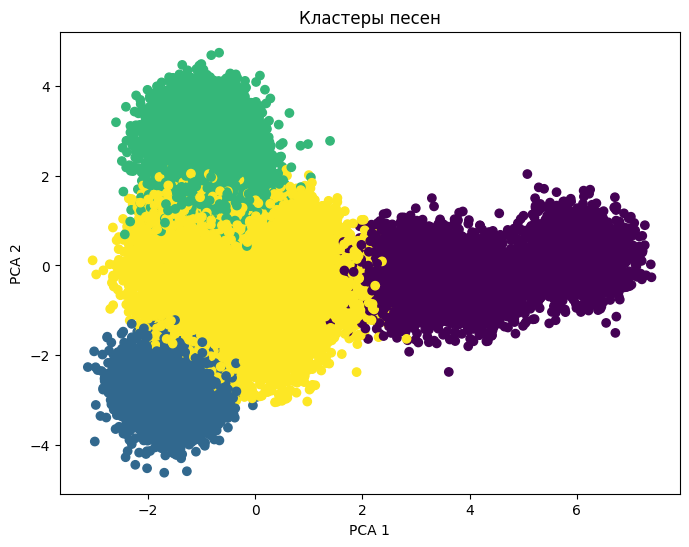

In [69]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, cmap='viridis')
plt.title("Кластеры песен")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()